In [1]:
# Histogram of track lifetimes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys 
import os
import seaborn as sns
import matplotlib.ticker as ticker

pythonPackagePath = os.path.abspath(r'D:\LLSM-CME-ANALYSIS\Final\src')
sys.path.append(pythonPackagePath)

from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax

In [2]:
###### Set the following variables #######


# Background intensity for each channel

background_channel_1 = 240
background_channel_2 = 150
background_channel_3 = 170

# framerate (in milliseconds)

framerate_msec = 2500

# protein names (optional)

channel1_name = 'Arp2/3-Halo'
channel2_name = 'Dynamin2-tagGFP2'
channel3_name = 'AP2-tagRFPt'

In [3]:
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0

# use this list to see all possible values to plot
# track_df.columns

In [4]:
filtered_tracks_control = pd.read_pickle(r'Z:\Abhi\LLSM_Analysis\controlOS_analysis\datasets\filtered_tracks_final.pkl')
filtered_tracks_treatment = pd.read_pickle(r'Z:\Abhi\LLSM_Analysis\41_OS_analysis\datasets\filtered_tracks_final.pkl')

In [5]:
# filtered_tracks_control
label1 = 'Control'
label2 = '4:1 OS 5-10min'

# label1 = 'Control1'
# label2 = 'Control2'

# label1 = 'CK689 50uM'
# label2 = 'CK666 50uM'

# title = 'CK689 vs CK666 50uM'
title = 'Control vs 4:1 OS 5-10min'

In [6]:
# region_to_plot = 'Apical'
# region_to_plot = 'Lateral'
# region_to_plot = 'Basal'
region_to_plot = 'All'

if region_to_plot == 'All':
    filtered_tracks_all_control = filtered_tracks_control.copy()
    filtered_tracks_all_treatment = filtered_tracks_treatment.copy()

if region_to_plot != 'All':
    filtered_tracks_all_control = filtered_tracks_control.copy()
    filtered_tracks_all_treatment = filtered_tracks_treatment.copy()
    filtered_tracks_all_control = filtered_tracks_all_control[filtered_tracks_all_control['membrane_region'] == region_to_plot]
    filtered_tracks_all_treatment = filtered_tracks_all_treatment[filtered_tracks_all_treatment['membrane_region'] == region_to_plot]

print('You are about to plot the following region: ', region_to_plot)

You are about to plot the following region:  All


In [7]:
# range of track lengths to plot in each cohort, in frames
custom_length_ranges = [[5, 10], [11,15], [16, 20], [21, 25], [26, 30], [31, 40], [41,90]]

In [8]:
# by default you always plot channel 3 positive (fixing this)

# e.g. [True, True] to plot all three channels
# or [True, False] to plot channels 1 and 2

plot_all_channels = False
channels_to_plot = [True, True]
if plot_all_channels:
    tracks_channel_subset_control = filtered_tracks_all_control.copy()
    tracks_channel_subset_treatment = filtered_tracks_all_treatment.copy()
else:
    channels_to_plot = channels_to_plot

    tracks_channel_subset_control = filtered_tracks_all_control[(filtered_tracks_all_control['channel1_positive'] == channels_to_plot[0]) &
                                    (filtered_tracks_all_control['channel2_positive'] == channels_to_plot[1])]

    tracks_channel_subset_treatment = filtered_tracks_all_treatment[(filtered_tracks_all_treatment['channel1_positive'] == channels_to_plot[0]) &
                                        (filtered_tracks_all_treatment['channel2_positive'] == channels_to_plot[1])]

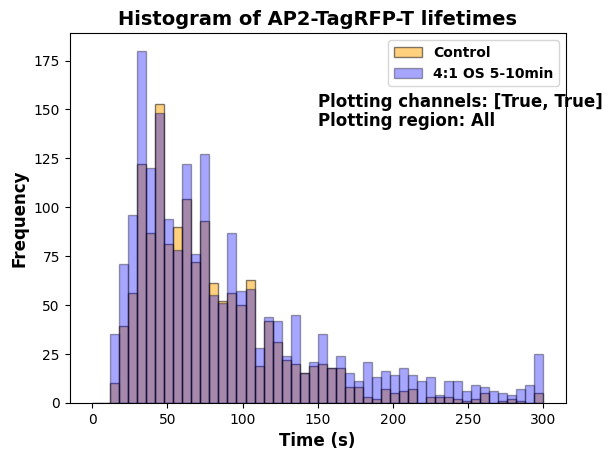

In [9]:
# Plot histogram of all track lengths (lifetimes)

# 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000


# Plot histograms of all_lifetimes_control and all_lifetimes_os
# on the same plot with 50 bins, and different colors
bins = np.linspace(0, 300, 51)  # Define the bin edges
plt.hist(all_lifetimes_control, bins=bins, color = 'orange', edgecolor='black', alpha=0.5, label=label1)
plt.hist(all_lifetimes_treatment, bins=bins, color = 'blue', edgecolor='black', alpha=0.35, label=label2)

plt.xlabel('Time (s)', fontsize = 12, weight = 'bold')  # X-axis label
plt.ylabel('Frequency', fontsize = 12, weight = 'bold')  # Y-axis label
plt.title('Histogram of AP2-TagRFP-T lifetimes', fontsize = 14, weight = 'bold')  # Title of the histogram
# Add labels for plot_all_channels, channels_to_plot, and region_to_plot
if plot_all_channels == True:
    plt.text(0.5, 0.8, f'Plotting all channels: {plot_all_channels}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
if plot_all_channels == False:
    plt.text(0.5, 0.8, f'Plotting channels: {channels_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
plt.text(0.5, 0.75, f'Plotting region: {region_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')

plt.legend(prop = {'weight':'bold'})
plt.show()

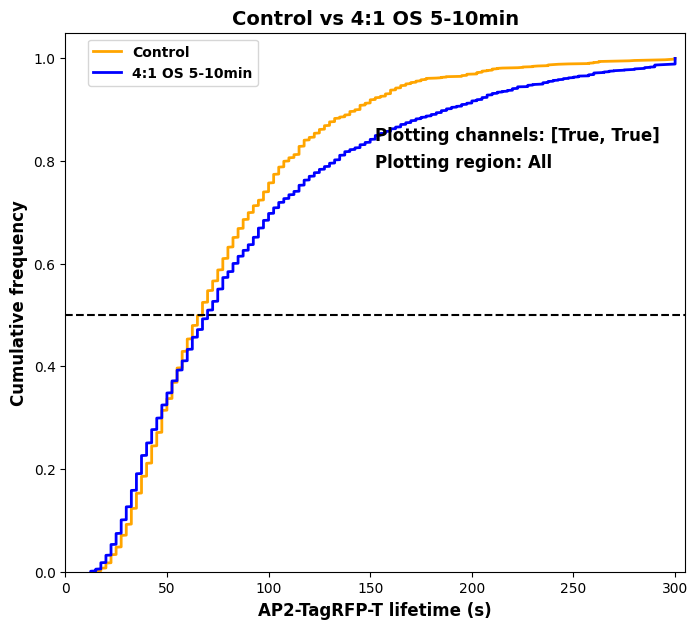

In [10]:
# Cumulative plot of track lifetimes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_cumulative_lifetime(dmso_df, ck666_df, conditions_list, title):
    plt.figure(figsize=(8, 7))

    # Define colors for conditions
    conditions = {conditions_list[0]: (dmso_df, 'orange'), conditions_list[1]: (ck666_df, 'blue')}
    
    for label, (df, color) in conditions.items():
        subset = np.sort(df['track_length'])
        cum_freq = np.arange(1, len(subset) + 1) / len(subset)
        plt.plot(subset, cum_freq, label=label, color=color, linewidth=2)

    # Formatting
    plt.xlabel('AP2-TagRFP-T lifetime (s)', fontsize=12, weight='bold')
    plt.ylabel('Cumulative frequency', fontsize=12, weight='bold')
    plt.xlim(0, 305)
    plt.ylim(0, 1.05)

    # Add horizontal dashed reference line at 0.5
    plt.axhline(0.5, linestyle="--", color="black")
    
    # Add shaded region (0-50s)
    # plt.axvspan(0, 50, color='brown', alpha=0.2)

    # Title and legend
    plt.title(title, fontsize=14, weight='bold')
    plt.legend(fontsize=12, loc='upper left', bbox_to_anchor=(0.025, 1), prop = {'weight':'bold'})

    # Show plot
    # plt.show()
    return plt


all_lifetimes_control_df = pd.DataFrame(all_lifetimes_control)
all_lifetimes_treatment_df = pd.DataFrame(all_lifetimes_treatment)

plt = plot_cumulative_lifetime(all_lifetimes_control_df, all_lifetimes_treatment_df, [label1, label2], title)
if plot_all_channels == True:
    plt.text(0.5, 0.8, f'Plotting all channels: {plot_all_channels}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
if plot_all_channels == False:
    plt.text(0.5, 0.8, f'Plotting channels: {channels_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
plt.text(0.5, 0.75, f'Plotting region: {region_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')

plt.show()

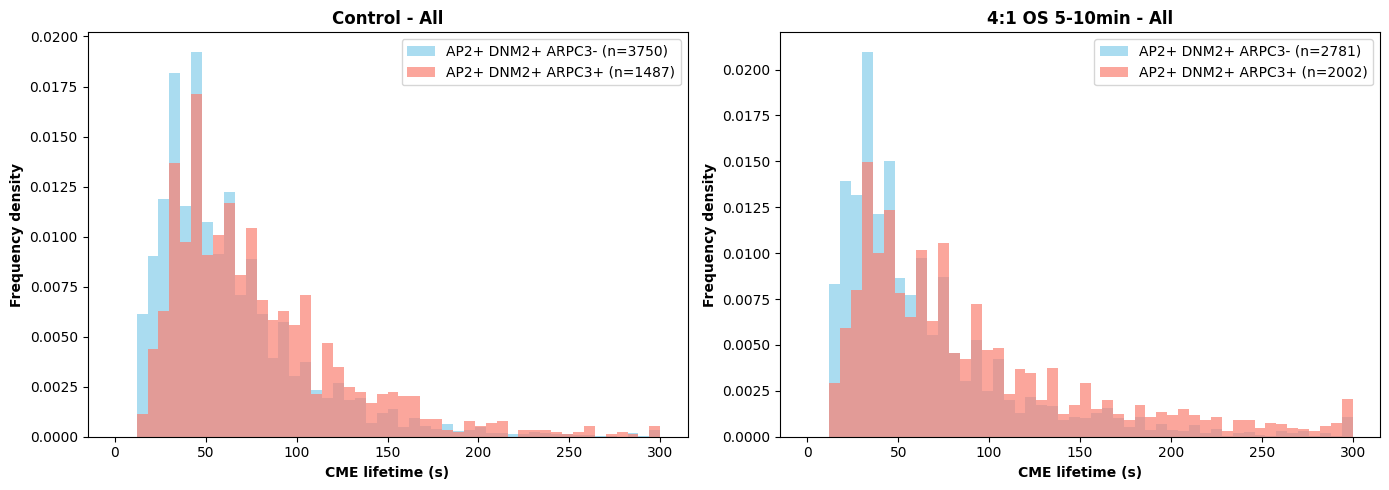

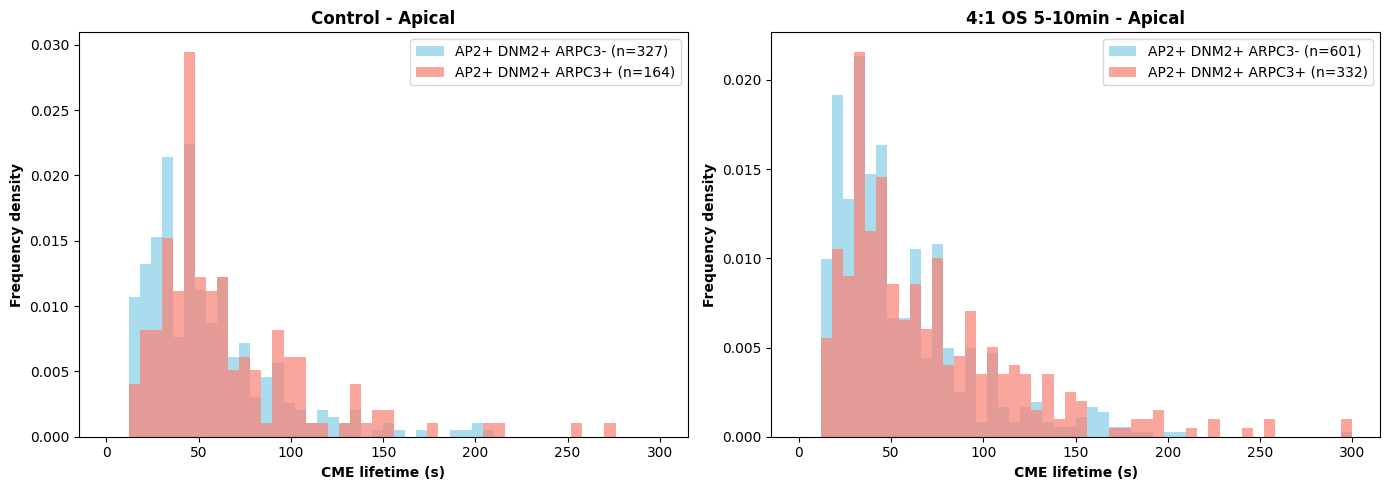

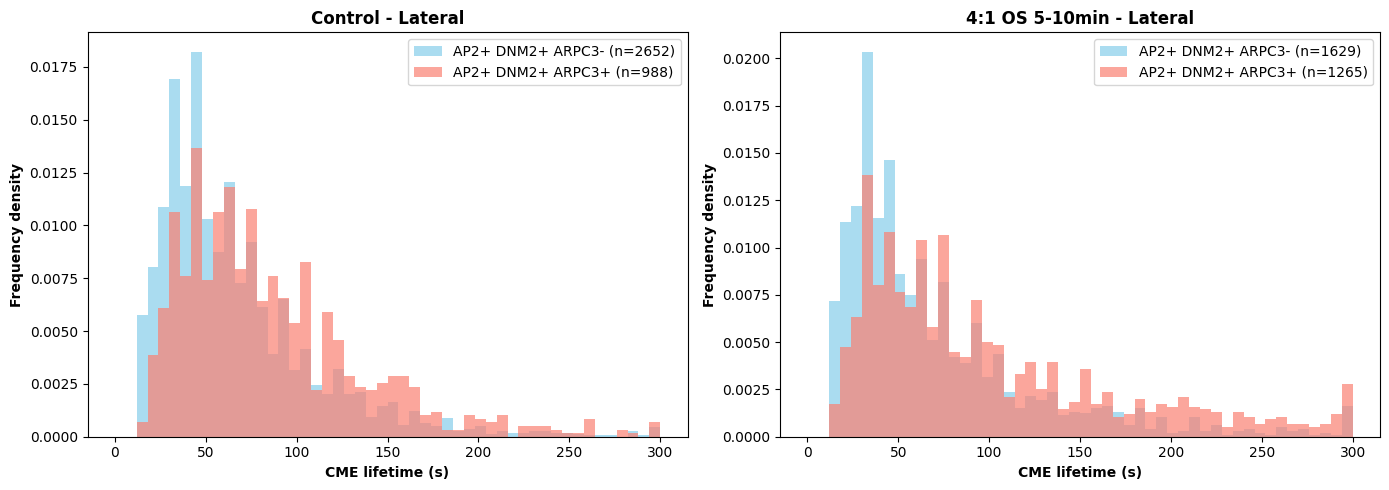

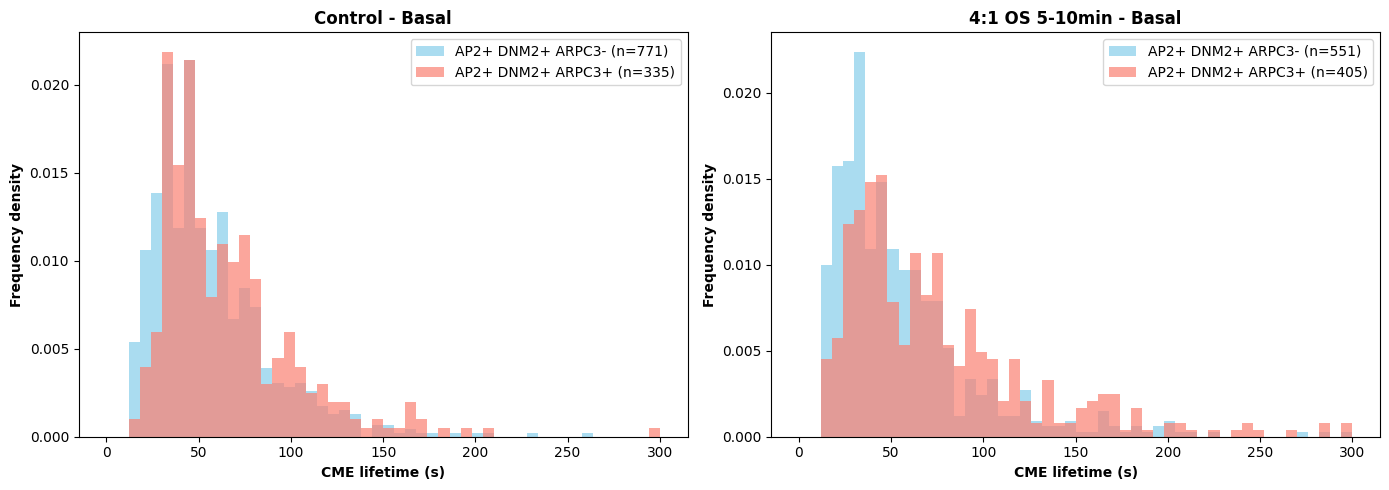

,Region,Condition,AP2+ DNM2+ ARPC3+ Count,AP2+ DNM2+ ARPC3- Count,AP2+ DNM2+ ARPC3+ Mean Lifetime (s),AP2+ DNM2+ ARPC3- Mean Lifetime (s)
0,All,Control,1487,3750,78.459987,63.441333
1,All,4:1 OS 5-10min,2002,2781,89.340659,64.715930
2,Apical,Control,164,327,65.030488,54.671254
3,Apical,4:1 OS 5-10min,332,601,70.331325,55.366057
4,Lateral,Control,988,2652,85.270749,66.702489
5,Lateral,4:1 OS 5-10min,1265,1629,98.843874,70.900859
6,Basal,Control,335,771,64.947761,55.943580
7,Basal,4:1 OS 5-10min,405,551,75.240741,56.628857


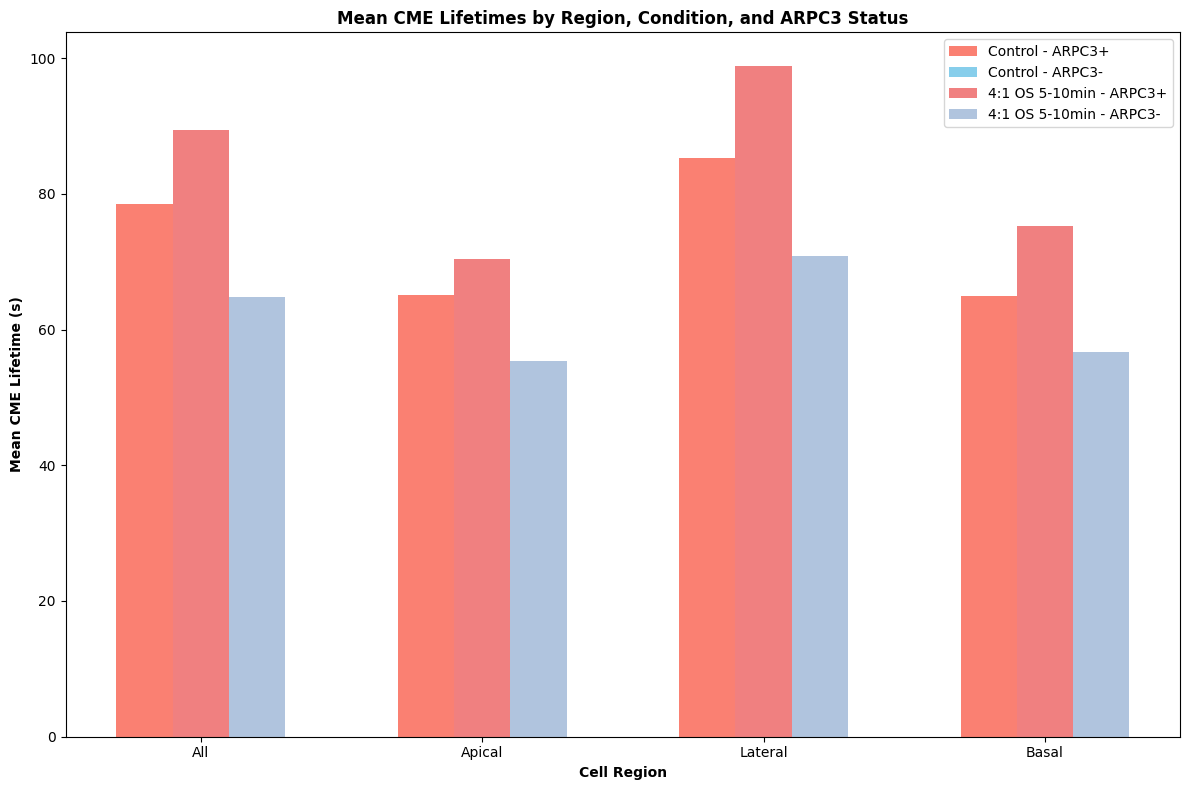

In [11]:
# # Set style parameters for better-looking plots
# plt.rcParams.update({'font.size': 12})
# sns.set_style("whitegrid")

# Function to plot the lifetime histograms for specified conditions
def plot_lifetime_by_region(control_df, os_df, label1, label2, region_name="All", normalize=True):
    """
    Plot lifetime histograms for tracks with AP2+ DNM2+ ARPC3- vs AP2+ DNM2+ ARPC3+
    
    Parameters:
    -----------
    control_df : DataFrame
        The control condition data
    os_df : DataFrame
        The osmotic shock data
    region_name : str
        The cell region to filter for (or "All")
    normalize : bool
        Whether to normalize the histograms (density=True)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Filter for region if specified
    if region_name != "All":
        control_subset = control_df[control_df['membrane_region'] == region_name].copy()
        os_subset = os_df[os_df['membrane_region'] == region_name].copy()
    else:
        control_subset = control_df.copy()
        os_subset = os_df.copy()
    
    # Convert track length to seconds
    control_subset['lifetime'] = control_subset['track_length'] * framerate_msec / 1000
    os_subset['lifetime'] = os_subset['track_length'] * framerate_msec / 1000
    
    # Define bins for consistency across plots
    bins = np.linspace(0, 300, 51)  # 0 to 160 seconds, 40 bins
    
    # Filter for AP2+ DNM2+ ARPC3+ and AP2+ DNM2+ ARPC3-
    for i, (df, title) in enumerate([(control_subset, f"{label1} - {region_name}"), 
                                     (os_subset, f"{label2} - {region_name}")]):
        # AP2+ is assumed for all tracks
        arpc3_pos = df[(df['channel1_positive'] == True) & (df['channel2_positive'] == True)]
        arpc3_neg = df[(df['channel1_positive'] == False) & (df['channel2_positive'] == True)]
        
        # Plot the histograms
        axes[i].hist(arpc3_neg['lifetime'], bins=bins, alpha=0.7, density=normalize,
                    color='skyblue', label='AP2+ DNM2+ ARPC3-')
        axes[i].hist(arpc3_pos['lifetime'], bins=bins, alpha=0.7, density=normalize,
                    color='salmon', label='AP2+ DNM2+ ARPC3+')
        
        # Add labels and legend
        axes[i].set_xlabel('CME lifetime (s)', fontweight='bold')
        if normalize:
            axes[i].set_ylabel('Frequency density', fontweight='bold')
        else:
            axes[i].set_ylabel('Count', fontweight='bold')
        axes[i].set_title(title, fontweight='bold')
        axes[i].legend()
        
        # Add track counts to the legend
        handles, labels = axes[i].get_legend_handles_labels()
        labels[0] += f" (n={len(arpc3_neg)})"
        labels[1] += f" (n={len(arpc3_pos)})"
        axes[i].legend(handles, labels)
    
    plt.tight_layout()
    return fig

# Create plots for each region
regions = ["All", "Apical", "Lateral", "Basal"]

# For each region, create and display the plot
for region in regions:
    fig = plot_lifetime_by_region(filtered_tracks_control, filtered_tracks_treatment, label1, label2, region_name=region)
    plt.show()


# Calculate statistics for a summary table
def calculate_region_stats(control_df, os_df, label1, label2):
    """Calculate summary statistics for each region and condition"""
    regions = ["All", "Apical", "Lateral", "Basal"]
    stats = []
    
    for region in regions:
        for df_name, df in [(label1, control_df), (label2, os_df)]:
            if region != "All":
                subset = df[df['membrane_region'] == region].copy()
            else:
                subset = df.copy()
                
            # Count AP2+ DNM2+ ARPC3+ and AP2+ DNM2+ ARPC3- tracks
            ap2_dnm2_arpc3_pos = subset[(subset['channel1_positive'] == True) & 
                                         (subset['channel2_positive'] == True)].copy()
            ap2_dnm2_arpc3_neg = subset[(subset['channel1_positive'] == False) & 
                                         (subset['channel2_positive'] == True)].copy()
            
            # Calculate mean lifetimes
            ap2_dnm2_arpc3_pos['lifetime'] = ap2_dnm2_arpc3_pos['track_length'] * framerate_msec / 1000
            ap2_dnm2_arpc3_neg['lifetime'] = ap2_dnm2_arpc3_neg['track_length'] * framerate_msec / 1000
            
            mean_pos = ap2_dnm2_arpc3_pos['lifetime'].mean() if len(ap2_dnm2_arpc3_pos) > 0 else 0
            mean_neg = ap2_dnm2_arpc3_neg['lifetime'].mean() if len(ap2_dnm2_arpc3_neg) > 0 else 0
            
            stats.append({
                "Region": region,
                "Condition": df_name,
                "AP2+ DNM2+ ARPC3+ Count": len(ap2_dnm2_arpc3_pos),
                "AP2+ DNM2+ ARPC3- Count": len(ap2_dnm2_arpc3_neg),
                "AP2+ DNM2+ ARPC3+ Mean Lifetime (s)": mean_pos,
                "AP2+ DNM2+ ARPC3- Mean Lifetime (s)": mean_neg
            })
    
    return pd.DataFrame(stats)

# Display summary statistics
stats_df = calculate_region_stats(filtered_tracks_control, filtered_tracks_treatment, label1, label2)
display(stats_df)

# Create a more visual plot of the mean lifetimes
plt.figure(figsize=(12, 8))

# Group by region and condition
grouped = stats_df.groupby(['Region', 'Condition'])

# For each region, plot the mean lifetimes for each condition and ARPC3 status
regions = ["All", "Apical", "Lateral", "Basal"]
pos = np.arange(len(regions))
width = 0.2  # Width of the bars

for i, cond in enumerate([label1, label2]):
    pos_means = [grouped.get_group((region, cond))["AP2+ DNM2+ ARPC3+ Mean Lifetime (s)"].values[0] 
                for region in regions]
    neg_means = [grouped.get_group((region, cond))["AP2+ DNM2+ ARPC3- Mean Lifetime (s)"].values[0] 
                for region in regions]
    
    plt.bar(pos + i*width - width/2, pos_means, width, 
            label=f"{cond} - ARPC3+", color='salmon' if i==0 else 'lightcoral')
    plt.bar(pos + i*width + width/2, neg_means, width, 
            label=f"{cond} - ARPC3-", color='skyblue' if i==0 else 'lightsteelblue')

plt.xlabel('Cell Region', fontweight='bold')
plt.ylabel('Mean CME Lifetime (s)', fontweight='bold')
plt.title('Mean CME Lifetimes by Region, Condition, and ARPC3 Status', fontweight='bold')
plt.xticks(pos + width/2, regions)
plt.legend()
plt.tight_layout()
plt.show()

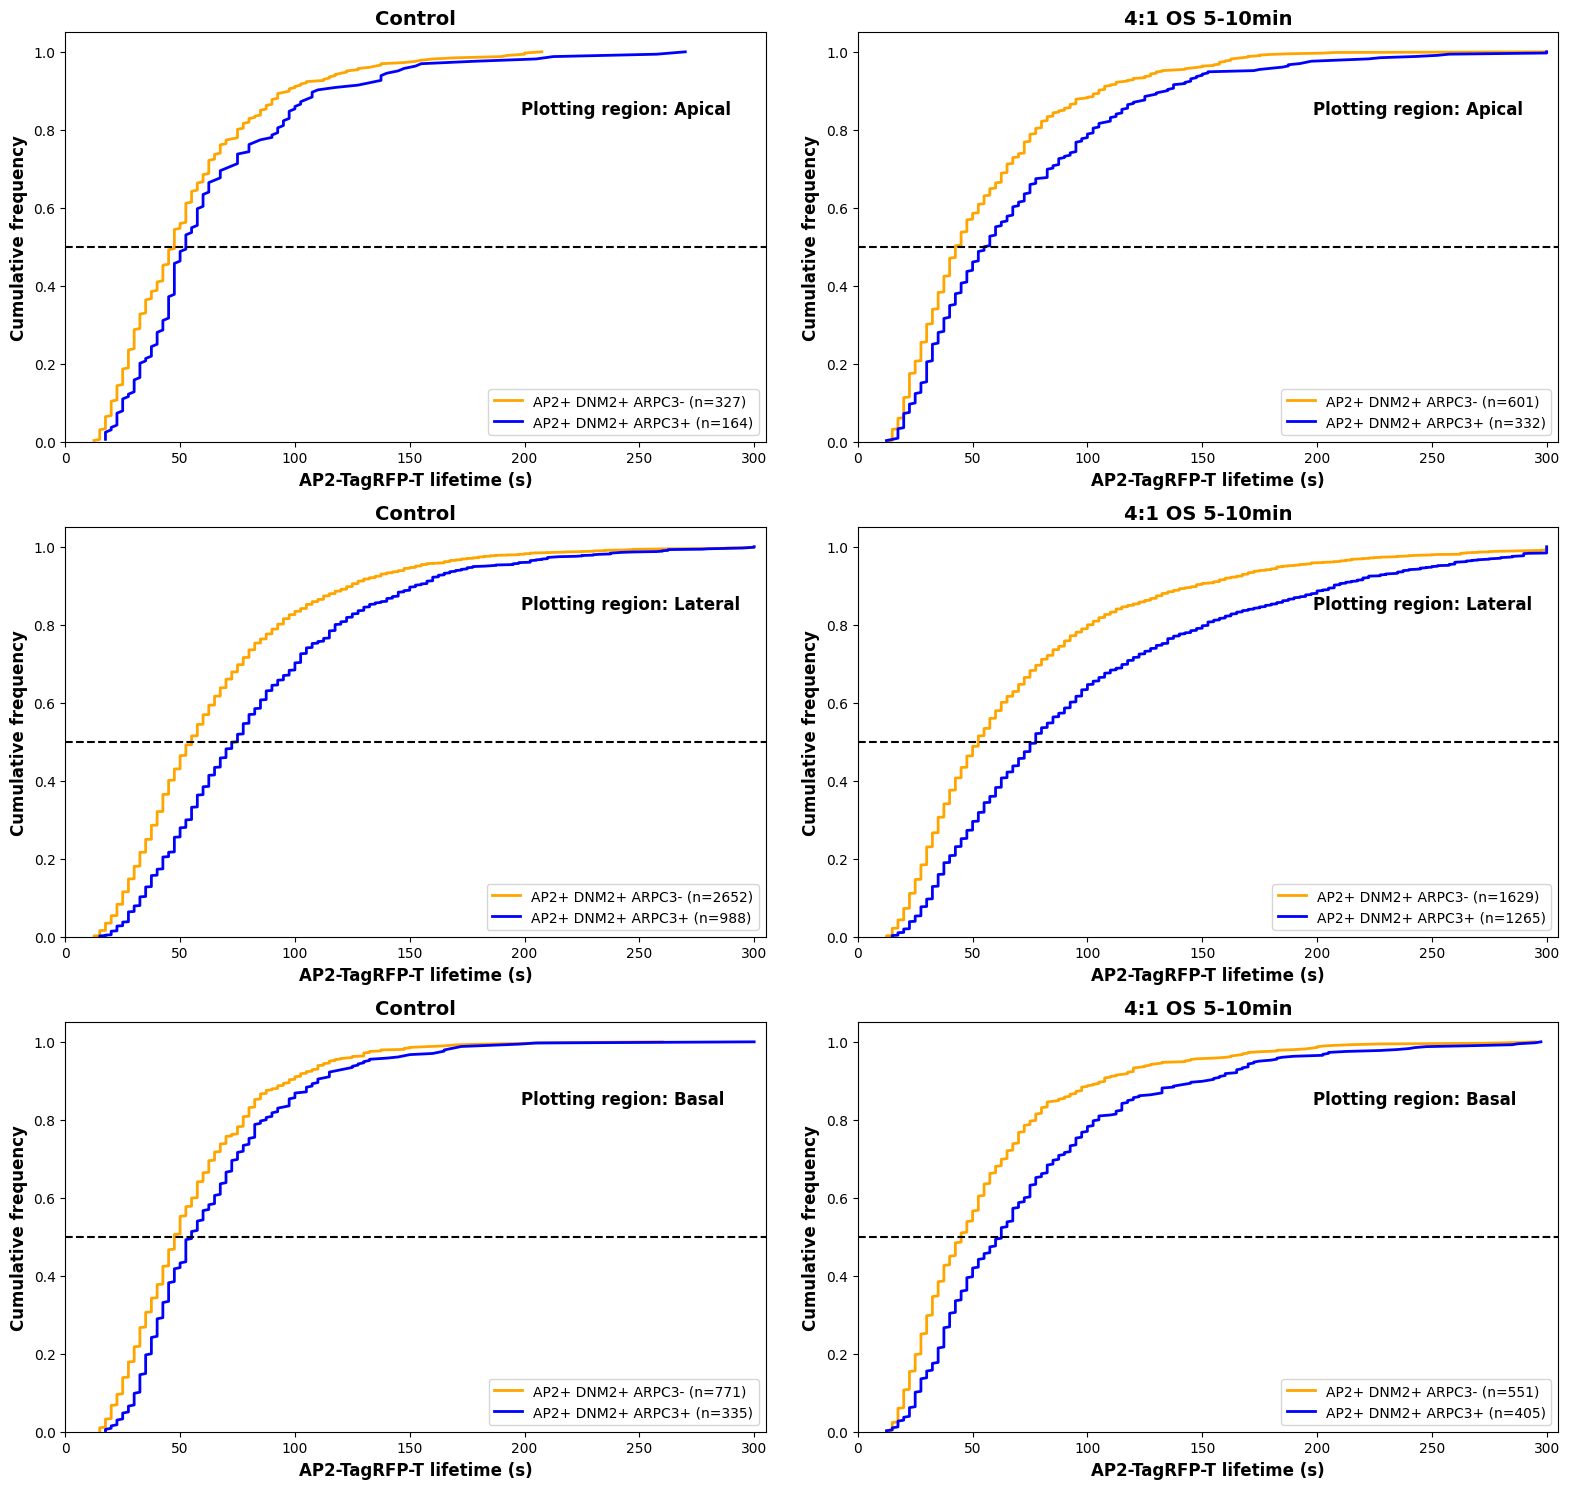

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_cumulative_lifetime_comparison(regions, filtered_tracks_control, filtered_tracks_OS, framerate_msec, label1, label2):
    """
    Create cumulative lifetime plots for different conditions and regions in a two-column layout.
    
    Parameters:
    -----------
    conditions : list
        List of dataframes for different conditions
    regions : list
        List of region names to plot
    filtered_tracks_control : DataFrame
        Control condition data
    filtered_tracks_OS : DataFrame
        Osmotic shock condition data
    framerate_msec : float
        Frame rate in milliseconds
    """
    # Create a figure with 2 columns (control and OS) and rows equal to number of regions
    fig, axes = plt.subplots(len(regions), 2, figsize=(16, 5 * len(regions)))
    
    # Titles for columns
    column_titles = [label1, label2]
    
    # Process each region
    for row_idx, region in enumerate(regions):
        # Process each condition (control and OS)
        for col_idx, (condition, title) in enumerate(zip([filtered_tracks_control, filtered_tracks_OS], column_titles)):
            # Get current axis
            if len(regions) == 1:
                ax = axes[col_idx]
            else:
                ax = axes[row_idx, col_idx]
            
            # Filter data by region
            df = condition.copy()
            df = df[df['membrane_region'] == region]
            
            # Separate positive and negative groups
            actin_positive = df[(df['channel1_positive'] == True) & (df['channel2_positive'] == True)]
            actin_negative = df[(df['channel1_positive'] == False) & (df['channel2_positive'] == True)]
            
            # Calculate lifetimes
            actin_positive_df = pd.DataFrame(actin_positive['track_length'] * framerate_msec / 1000)
            actin_negative_df = pd.DataFrame(actin_negative['track_length'] * framerate_msec / 1000)
            
            # Define colors for conditions
            conditions_list = ['AP2+ DNM2+ ARPC3-', 'AP2+ DNM2+ ARPC3+']
            condition_data = {
                conditions_list[0]: (actin_negative_df, 'orange'), 
                conditions_list[1]: (actin_positive_df, 'blue')
            }
            
            # Plot cumulative distribution
            for label, (df_subset, color) in condition_data.items():
                subset = np.sort(df_subset['track_length'])
                cum_freq = np.arange(1, len(subset) + 1) / len(subset)
                ax.plot(subset, cum_freq, label=label, color=color, linewidth=2)
            
            # Add track counts to the legend
            legend_labels = [
                f"{conditions_list[0]} (n={len(actin_negative_df)})",
                f"{conditions_list[1]} (n={len(actin_positive_df)})"
            ]
            
            # Formatting
            ax.set_xlabel('AP2-TagRFP-T lifetime (s)', fontsize=12, weight='bold')
            ax.set_ylabel('Cumulative frequency', fontsize=12, weight='bold')
            ax.set_xlim(0, 305)
            ax.set_ylim(0, 1.05)
            
            # Add horizontal dashed reference line at 0.5
            ax.axhline(0.5, linestyle="--", color="black")
            
            # Add title and region label
            ax.set_title(f"{title}", fontsize=14, weight='bold')
            ax.text(0.65, 0.8, f'Plotting region: {region}', 
                   transform=ax.transAxes, fontsize=12, weight='bold')
            
            # Add legend to top right
            ax.legend(legend_labels, fontsize=10, loc='lower right')
    
    plt.tight_layout()
    return fig

# Define conditions and regions
conditions = [filtered_tracks_control, filtered_tracks_treatment]
regions = ["Apical", "Lateral", "Basal"]

# Create and display the plots
fig = plot_cumulative_lifetime_comparison(regions, filtered_tracks_control, filtered_tracks_treatment, framerate_msec, label1, label2)
plt.show()

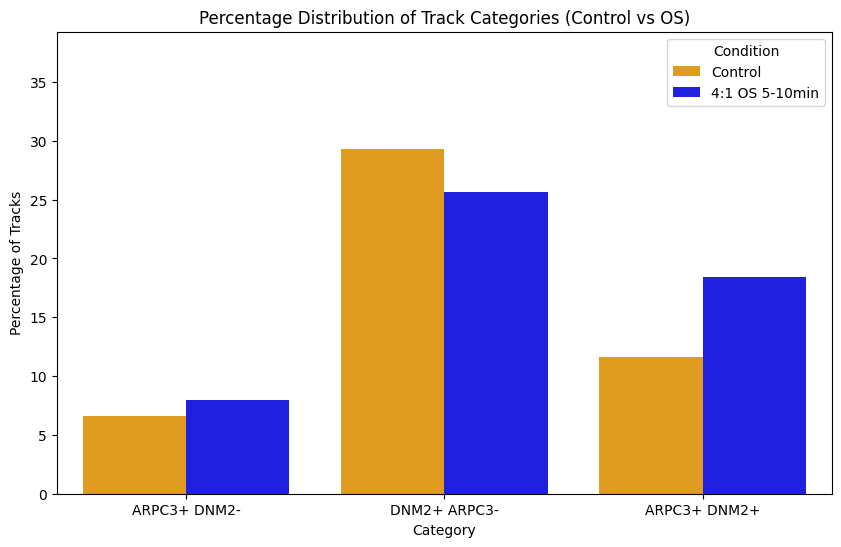

In [13]:
# Function to calculate percentages
def calculate_percentages(df):
    total_tracks = df['track_id'].nunique()
    c1_plus_c2_minus = df[(df['channel1_positive']) & (~df['channel2_positive'])]['track_id'].nunique() / total_tracks * 100
    c2_plus_c1_minus = df[(df['channel2_positive']) & (~df['channel1_positive'])]['track_id'].nunique() / total_tracks * 100
    double_positive = df[(df['channel1_positive']) & (df['channel2_positive'])]['track_id'].nunique() / total_tracks * 100
    
    return {'ARPC3+ DNM2-': c1_plus_c2_minus, 'DNM2+ ARPC3-': c2_plus_c1_minus, 'ARPC3+ DNM2+': double_positive}

# Compute percentages for each condition
control_percentages = calculate_percentages(filtered_tracks_control)
os_percentages = calculate_percentages(filtered_tracks_treatment)

# Convert to DataFrame for plotting
data = []
for condition, percentages in zip([label1, label2], [control_percentages, os_percentages]):
    for category, value in percentages.items():
        data.append({'Condition': condition, 'Category': category, 'Percentage': value})

df_plot = pd.DataFrame(data)

# Plot using seaborn barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Percentage', hue='Condition', data=df_plot, palette={label1: 'orange', label2: 'blue'}, capsize=0.1)

# Customize plot
plt.xlabel("Category")
plt.ylabel("Percentage of Tracks")
plt.title("Percentage Distribution of Track Categories (Control vs OS)")
plt.legend(title="Condition")
plt.ylim(0, df_plot['Percentage'].max() + 10)  # Adjust y-axis for better visualization
plt.show()

Plotting region: All
Control tracks: 12814
OS tracks: 10861
Plotting region: Apical
Control tracks: 1997
OS tracks: 2676
Plotting region: Lateral
Control tracks: 7071
OS tracks: 5268
Plotting region: Basal
Control tracks: 3746
OS tracks: 2917


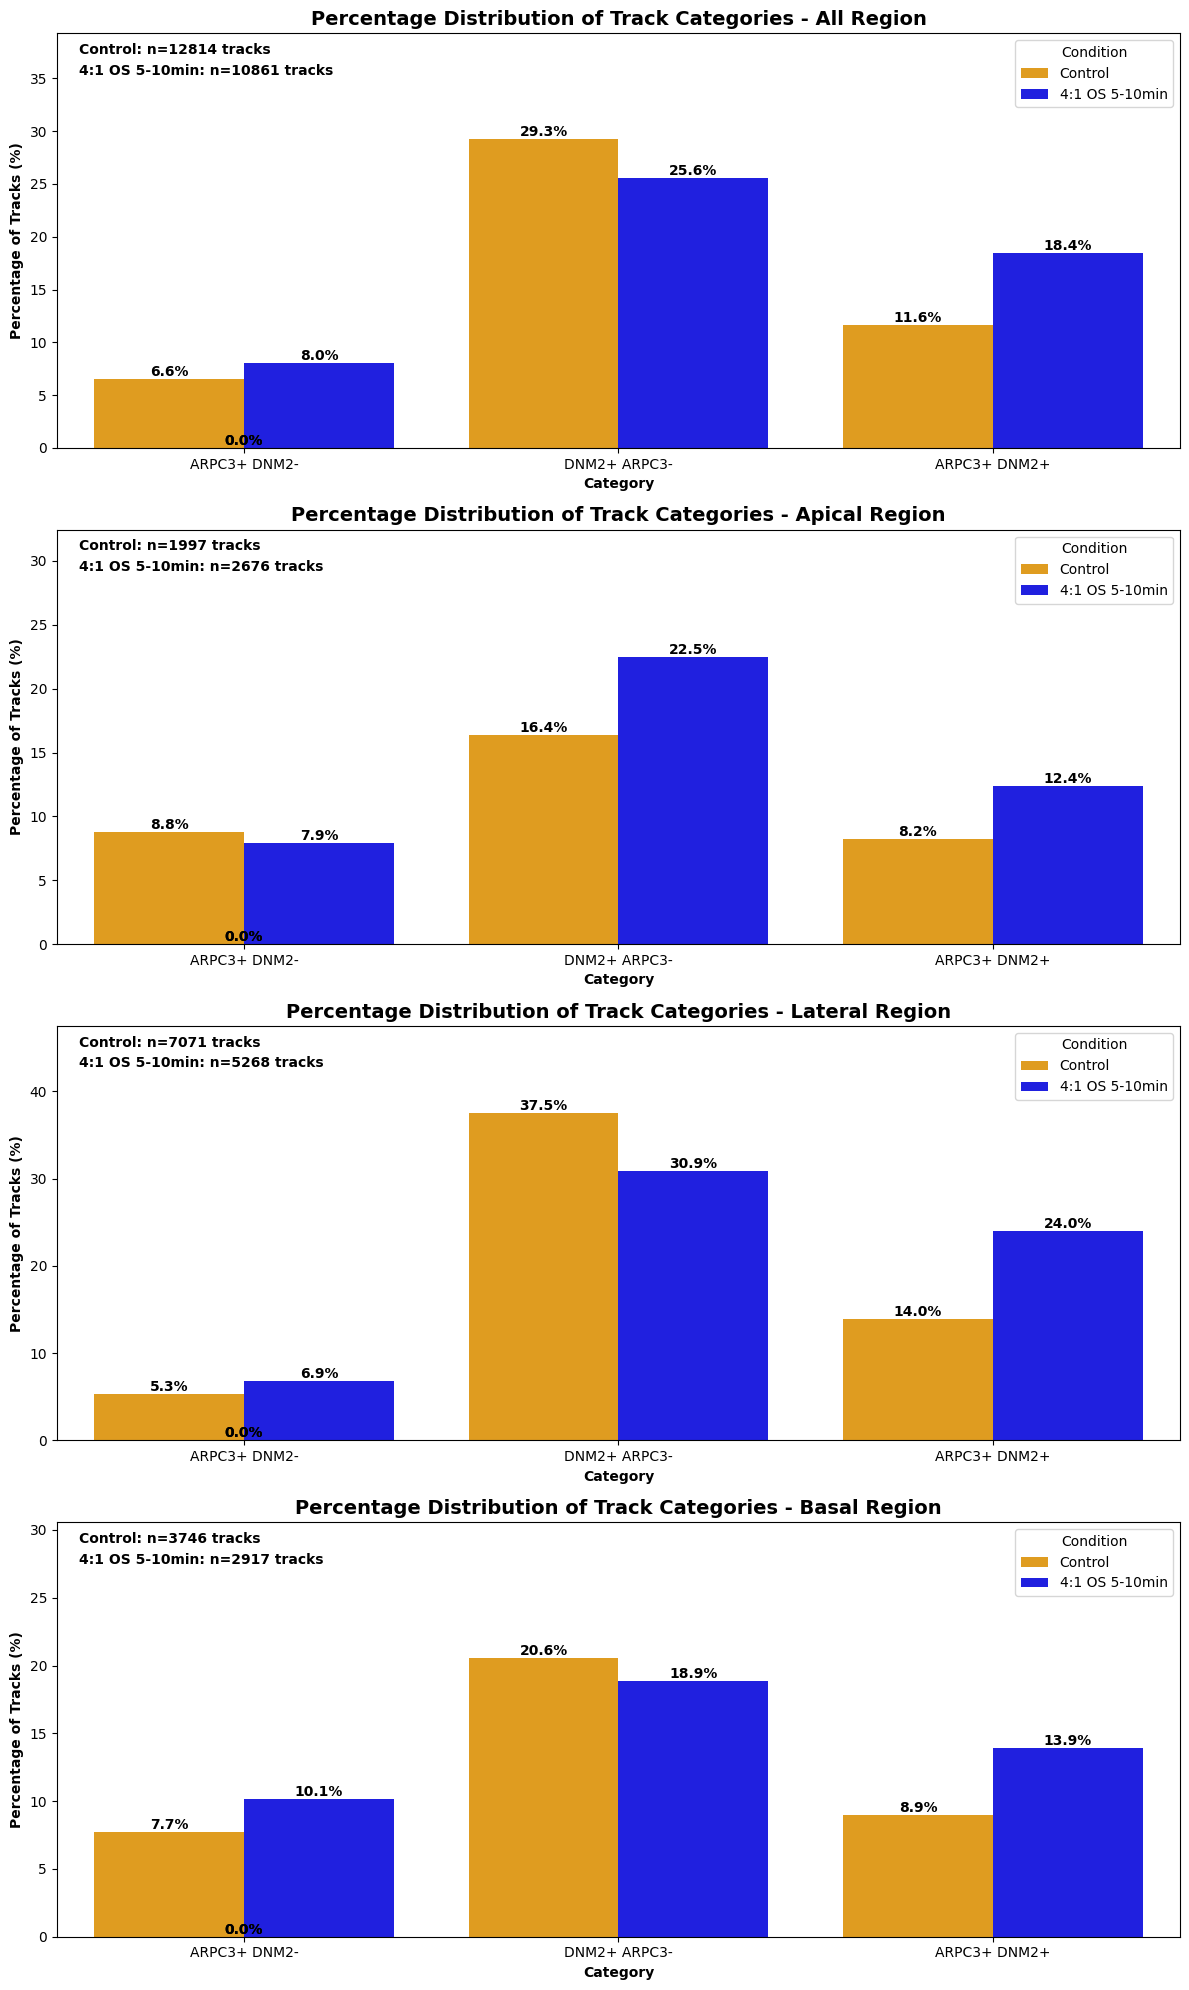

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

def plot_percentages_by_region(filtered_tracks_control, filtered_tracks_OS, label1, label2):
    """
    Plot percentages of track categories across different regions for control and OS conditions.
    
    Parameters:
    -----------
    filtered_tracks_control : DataFrame
        Control condition data
    filtered_tracks_OS : DataFrame
        Osmotic shock data
    """
    # Define regions to plot
    regions = ["All", "Apical", "Lateral", "Basal"]
    
    # Function to calculate percentages
    def calculate_percentages(df):
        total_tracks = df['track_id'].nunique()
            
        c1_plus_c2_minus = df[(df['channel1_positive']) & (~df['channel2_positive'])]['track_id'].nunique() / total_tracks * 100
        c2_plus_c1_minus = df[(df['channel2_positive']) & (~df['channel1_positive'])]['track_id'].nunique() / total_tracks * 100
        double_positive = df[(df['channel1_positive']) & (df['channel2_positive'])]['track_id'].nunique() / total_tracks * 100
        
        return {'ARPC3+ DNM2-': c1_plus_c2_minus, 'DNM2+ ARPC3-': c2_plus_c1_minus, 'ARPC3+ DNM2+': double_positive}
    
    # Create a figure with subplots - one row for each region
    fig, axes = plt.subplots(len(regions), 1, figsize=(12, 5 * len(regions)))
    
    # Process each region
    for i, region in enumerate(regions):
        # Filter data for the current region
        if region == 'All':
            filtered_region_control = filtered_tracks_control.copy()
            filtered_region_OS = filtered_tracks_OS.copy()
        else:
            filtered_region_control = filtered_tracks_control[filtered_tracks_control['membrane_region'] == region].copy()
            filtered_region_OS = filtered_tracks_OS[filtered_tracks_OS['membrane_region'] == region].copy()
        
        # Print info about the region being plotted
        print(f'Plotting region: {region}')
        print(f'Control tracks: {filtered_region_control["track_id"].nunique()}')
        print(f'OS tracks: {filtered_region_OS["track_id"].nunique()}')
        
        # Compute percentages for each condition
        control_percentages = calculate_percentages(filtered_region_control)
        os_percentages = calculate_percentages(filtered_region_OS)
        
        # Convert to DataFrame for plotting
        data = []
        for condition, percentages in zip([label1, label2], [control_percentages, os_percentages]):
            for category, value in percentages.items():
                data.append({'Condition': condition, 'Category': category, 'Percentage': value})
        
        df_plot = pd.DataFrame(data)
        
        # Get current axis
        ax = axes[i] if len(regions) > 1 else axes
        
        # Plot using seaborn barplot
        sns.barplot(x='Category', y='Percentage', hue='Condition', data=df_plot, 
                   palette={label1: 'orange', label2: 'blue'}, 
                   capsize=0.1, ax=ax)
        
        # Add track counts as text annotations
        for j, condition in enumerate([label1, label2]):
            track_count = filtered_region_control["track_id"].nunique() if condition == label1 else filtered_region_OS["track_id"].nunique()
            ax.text(0.02, 0.95 - j*0.05, f'{condition}: n={track_count} tracks', 
                   transform=ax.transAxes, fontsize=10, fontweight='bold')
        
        # Customize plot
        ax.set_xlabel("Category", fontweight='bold')
        ax.set_ylabel("Percentage of Tracks (%)", fontweight='bold')
        ax.set_title(f"Percentage Distribution of Track Categories - {region} Region", fontsize=14, fontweight='bold')
        ax.legend(title="Condition", loc='upper right')
        ax.set_ylim(0, min(100, df_plot['Percentage'].max() + 10))  # Adjust y-axis for better visualization
        
        # Add percentage values on top of bars
        for p in ax.patches:
            ax.annotate(f'{p.get_height():.1f}%', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    return fig

# Create and display the plots
fig = plot_percentages_by_region(filtered_tracks_control, filtered_tracks_treatment, label1, label2)
plt.show()

In [15]:
# Plot distribution of max ArpC3/max AP2 ratios per cell surface
def plot_arpc3_ap2_ratio_distribution(control_df, os_df, label1, label2, plot_title=None):
    """
    Create boxplots showing the distribution of max ArpC3/max AP2 ratios
    across different surface regions (apical, lateral, basal) with median values displayed.
    
    Parameters:
    -----------
    control_df : DataFrame
        The control condition data
    os_df : DataFrame
        The osmotic shock data
    label1 : str
        Label for control condition
    label2 : str
        Label for treatment condition
    plot_title : str
        Title for the plot
    """
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Define regions and their positions on x-axis
    regions = ['Apical', 'Lateral', 'Basal']
    x_positions = np.arange(len(regions))
    width = 0.35  # Width of bars
    
    # Colors for conditions (matching your style)
    control_color = 'orange'
    os_color = 'blue'
    
    # Lists to store boxplot data and their positions
    boxplot_data = []
    box_positions = []
    
    # Process each region - calculate max ArpC3/max AP2 ratio for each track
    for i, region in enumerate(regions):
        # Filter data for this region
        control_region = control_df[control_df['membrane_region'] == region]
        os_region = os_df[os_df['membrane_region'] == region]
        
        # Calculate max ArpC3/max AP2 ratio for control tracks
        control_ratios = []
        for idx, row in control_region.iterrows():
            max_arpc3 = max(row['C1_adjusted_voxel_sum'])  # Max ArpC3 for this track
            max_ap2 = max(row['C3_adjusted_voxel_sum'])    # Max AP2 for this track
            if max_ap2 > 0:  # Avoid division by zero
                ratio = max_arpc3 / max_ap2
                control_ratios.append(ratio)
        
        # Calculate max ArpC3/max AP2 ratio for treatment tracks
        os_ratios = []
        for idx, row in os_region.iterrows():
            max_arpc3 = max(row['C1_adjusted_voxel_sum'])  # Max ArpC3 for this track
            max_ap2 = max(row['C3_adjusted_voxel_sum'])    # Max AP2 for this track
            if max_ap2 > 0:  # Avoid division by zero
                ratio = max_arpc3 / max_ap2
                os_ratios.append(ratio)
        
        # Calculate positions for boxplots
        control_pos = i - width/2
        os_pos = i + width/2
        
        # Add positions and data to lists
        box_positions.extend([control_pos, os_pos])
        boxplot_data.extend([control_ratios, os_ratios])
    
    # Create boxplots
    bp = ax.boxplot(boxplot_data, positions=box_positions, widths=width*0.8, patch_artist=True)
    
    # Color the boxplots and add median values
    for i, box in enumerate(bp['boxes']):
        if i % 2 == 0:  # Control
            box.set(facecolor=control_color, alpha=0.5)
        else:  # OS
            box.set(facecolor=os_color, alpha=0.35)
    
    # Set median line colors to black and add median value labels
    for i, median in enumerate(bp['medians']):
        median.set(color='black', linewidth=1.5)
        
        # Get median line position and value
        xdata = median.get_xdata()
        ydata = median.get_ydata()
        x = xdata.mean()
        y = ydata[0]
        
        # Position text based on whether it's control (even index) or treatment (odd index)
        if i % 2 == 0:
            # Control: place text to the left
            ax.text(x - 0.15, y, f'{y:.2f}', ha='right', va='center', 
                   fontsize=10, weight='bold', color='black')
        else:
            # Treatment: place text to the right  
            ax.text(x + 0.15, y, f'{y:.2f}', ha='left', va='center', 
                   fontsize=10, weight='bold', color='black')
    
    # Add horizontal lines connecting medians within each region
    for i in range(len(regions)):
        control_idx = i * 2
        os_idx = i * 2 + 1
        
        if control_idx < len(bp['medians']) and os_idx < len(bp['medians']):
            control_median_y = bp['medians'][control_idx].get_ydata()[0]
            os_median_y = bp['medians'][os_idx].get_ydata()[0]
            
            # Draw horizontal line at the lower median value
            median_y = min(control_median_y, os_median_y)
            control_pos = i - width/2
            os_pos = i + width/2
            ax.hlines(y=median_y, xmin=control_pos, xmax=os_pos, 
                     color='grey', linewidth=0.5, linestyle='--')
    
    # Set x-axis ticks and labels
    ax.set_xticks(x_positions)
    ax.set_xticklabels(regions, fontweight='bold', fontsize=12)
    
    # Add legend
    control_patch = plt.Rectangle((0, 0), 1, 1, facecolor=control_color, alpha=0.5)
    os_patch = plt.Rectangle((0, 0), 1, 1, facecolor=os_color, alpha=0.35)
    ax.legend([control_patch, os_patch], [label1, label2], 
             loc='upper left', fontsize=12, frameon=True, fancybox=True, 
             prop={'weight':'bold'})
    
    # Set labels and title
    ax.set_ylabel('Normalized Intensity (A.U.)', fontsize=12, fontweight='bold')
    ax.set_title(plot_title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    return fig

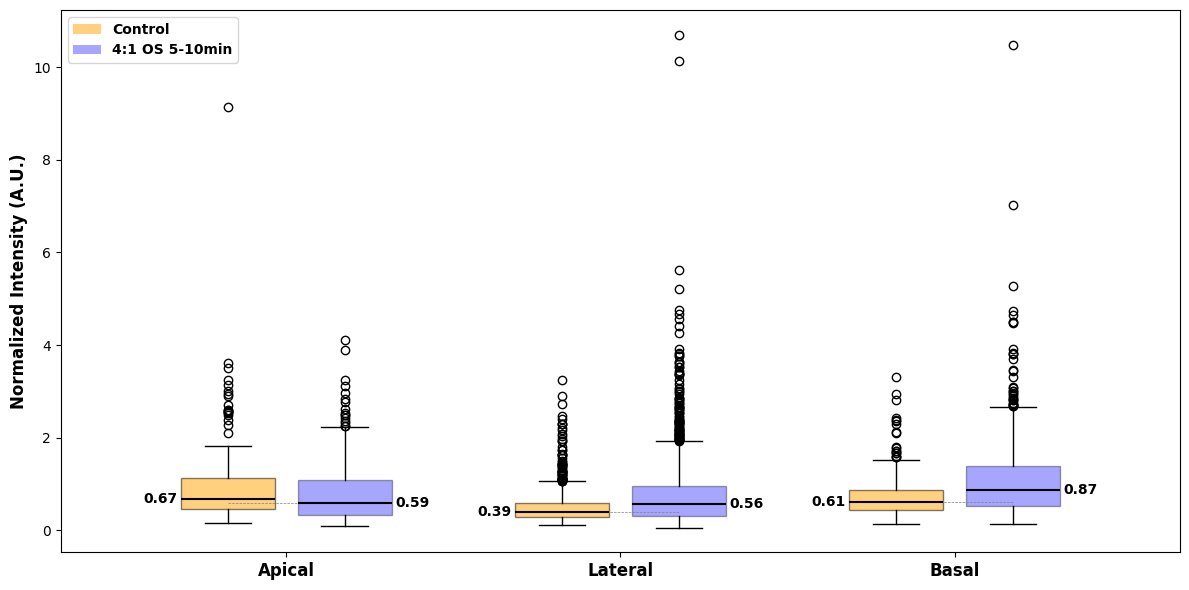

In [16]:
# Filter channels if needed
plot_all_channels = False
channels_to_plot = [True, True]

if plot_all_channels:
    tracks_control = filtered_tracks_control.copy()
    tracks_treatment = filtered_tracks_treatment.copy()
else:
    tracks_control = filtered_tracks_control[
        (filtered_tracks_control['channel1_positive'] == channels_to_plot[0]) &
        (filtered_tracks_control['channel2_positive'] == channels_to_plot[1])
    ]
    tracks_treatment = filtered_tracks_treatment[
        (filtered_tracks_treatment['channel1_positive'] == channels_to_plot[0]) &
        (filtered_tracks_treatment['channel2_positive'] == channels_to_plot[1])
    ]

label1 = 'Control'
label2 = '4:1 OS 5-10min'

# Create the plot
fig = plot_arpc3_ap2_ratio_distribution(tracks_control, tracks_treatment, 
                                      label1=label1, label2=label2)
plt.show()

In [17]:
# For control alone, looking at lifetimes on apical, lateral, and basal regions
# And the fraction of tracks in different lifetime ranges
def plot_lifetime_distribution_by_region(tracks_df, region_name, framerate_msec, label):
    """
    Plot lifetime distribution for a specific region.
    
    Parameters:
    -----------
    tracks_df : DataFrame
        DataFrame containing track data
    region_name : str
        Name of the region to filter tracks by
    framerate_msec : float
        Frame rate in milliseconds
    label : str
        Label for the plot title
    """
    # Filter tracks by region
    tracks_region = tracks_df[tracks_df['membrane_region'] == region_name].copy()
    
    # Calculate lifetimes in seconds
    tracks_region['lifetime'] = tracks_region['track_length'] * framerate_msec / 1000
    
    # Plot histogram of lifetimes
    plt.figure(figsize=(10, 6))
    bins = np.linspace(0, 300, 51)  # Define the bin edges
    sns.histplot(tracks_region['lifetime'], bins=bins, kde=False, color='orange')
    
    # Add labels and title
    plt.xlabel('CME Lifetime (s)', fontsize=12, weight='bold')
    plt.ylabel('Number of tracks', fontsize=12, weight='bold')
    plt.title(f'{label} - {region_name} Region', fontsize=14, weight='bold')

    # Add text with mean and standard deviation
    mean_lifetime = tracks_region['lifetime'].mean()
    std_lifetime = tracks_region['lifetime'].std()
    plt.text(0.82, 0.905, f'Mean: {mean_lifetime:.2f} s\nStd: {std_lifetime:.2f} s', 
             transform=plt.gca().transAxes, fontsize=12, weight='bold', 
             bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))
    
    # Show plot
    plt.show()

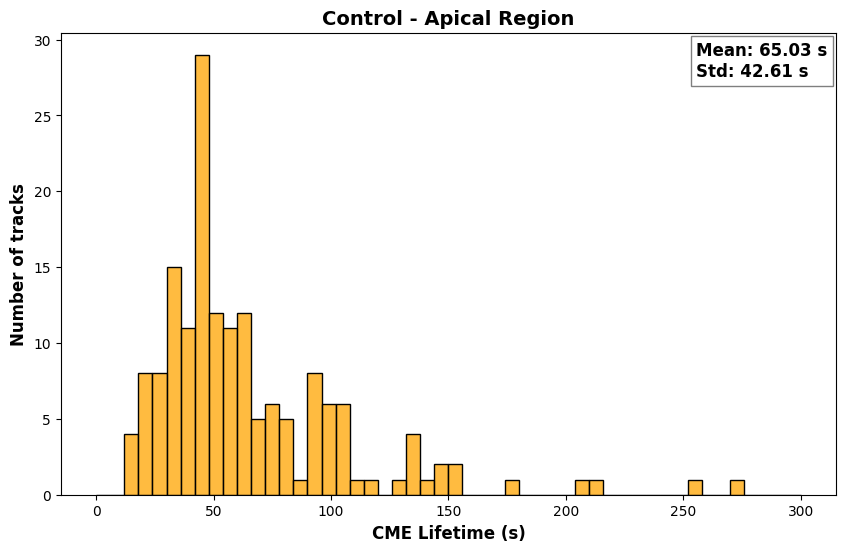

In [18]:
triple_positive_tracks = filtered_tracks_control[
    (filtered_tracks_control['channel1_positive'] == True) &
    (filtered_tracks_control['channel2_positive'] == True)
]
# For control alone, looking at lifetimes on apical, lateral, and basal regions
# And the fraction of tracks in different lifetime ranges
plot_lifetime_distribution_by_region(triple_positive_tracks, 'Apical', framerate_msec, label='Control')

Calculating Growth Rate Distributions (from Kenny) for Control vs OS, and ArpC3 negative versus positive tracks

In [19]:
def group_intensities_trackid(track,track_id, column_name='C3_adjusted_voxel_sum'):
    """
    Extracts the AP2 intensitied on a specific track

    track(pd.Dataframe): The dataframe you are extracting data from
    track_id(int): The track_id to extract
    """
    track_data = track[track['track_id'] == track_id].copy(deep = True)
    
    
    # return track_data['c3_voxel_sum_adjusted'].tolist()
    return track_data[column_name].tolist()

In [20]:
def extract_slope(intensities, framerate_msec: int, time_interval: int = 12, forwardp: float = 0.25, background_channel_3: int = 170):
    """
    Extracts slopes from AP2 intensities

    1. intensities(list): A list that contains np.arrays of intensities
    2. framerate_msec(int): The framerate in milliseconds
    3. time_interval(int): Time interval to extract the slopes. Default is 12 seconds
    4. fowardp(float): look foward in time? unsure more details below
    5. background_channel_3(int): The background intensity for AP2. I put the default as 170 as that is what I found in other notebooks
    """
    # Defining frame range of 12 seconds to fit the line
    # time interval in seconds
    import math

    prange = time_interval/(framerate_msec/1000)  # Convert time interval to seconds
    if prange < 3:
        prange = 3
    # From Ferguson et al. (2016), originally designed to analyze data using no future knowledge, you can
    # adjust the percent of the frame range that looks forward in time.
    # adjusting this should change the shape of histograms, so maintain
    # consistency while comparing analyses.
    #forwardp = 0.25
    front = math.ceil(forwardp * (prange-1))
    rear = math.floor((1-forwardp) * (prange-1))

    slopes = []
    for i, intensity in enumerate(intensities):
        lint = len(intensity)
        # intdiff = np.zeros(lint) # this will introduce additional zeros to the distrbution, which we don't want
        intdiff = []
        if lint <= prange:
            # Skip to next track if not enough data points
            continue
            # slopes.append(intdiff) # Don't think we should return empty slopes, since slope of 0 means stalled endocytosis
        # performing least squares fitting
        # curmax = np.max(intensity) - background_channel_3 # we are already using adjusted intensities, so no need to subtract background here
        curmax = np.max(intensity)  # Use the maximum intensity directly
        for j in range(rear, lint - front):
            sub_start = max(0, j - rear)
            sub_end = min(lint, j + front + 1)
            sub_indices = np.arange(sub_start, sub_end)

            # temp = (intensity[sub_indices] - background_channel_3) / curmax # we are already using adjusted intensities, so no need to subtract background here
            temp = intensity[sub_indices] / curmax  # Use the maximum intensity directly
            tempx = sub_indices * (framerate_msec/1000)
            tempy = temp

            n = len(tempx)
            numer = n * np.sum(tempx * tempy) - np.sum(tempx) * np.sum(tempy)
            denom = n * np.sum(tempx ** 2) - (np.sum(tempx)) ** 2
            if denom != 0:
                intdiff.append(numer / denom)
            else:
                # intdiff[j] = 0 # this will introduce additional zeros to the distrbution, which we don't want
                # skip this point if denominator is zero
                continue
        slopes.append(np.array(intdiff))
    return slopes

In [21]:
def growth_distribution(track, framerate_msec, time_interval, forwardp=0.25):
    """
    Computes the CCS growth distribution of the WHOLE dataframe

    track(pd.Dataframe): The dataframe to perform growth_distribution
    framerate_msec(int): The framerate in milliseconds
    time_interval(int): The time interval to extract slopes
    fowardp(float): Refer to slope_extract
    """
    from tqdm import tqdm
    all_slopes = []
    for trackid in tqdm(track['track_id'].unique(), desc="Processing tracks"):
        # testing = [np.array(group_intensities_trackid(track, trackid))] # this was throwing an error
        testing = np.array(group_intensities_trackid(track, trackid))
        gathered_slopes = extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp)
        all_slopes = all_slopes + gathered_slopes[0].tolist()
        #print(len(all_slopes))
        #trackid_done.add(trackid)
        #print(f'{trackid} done')
    return all_slopes

Processing tracks: 100%|██████████| 2002/2002 [00:04<00:00, 442.47it/s]


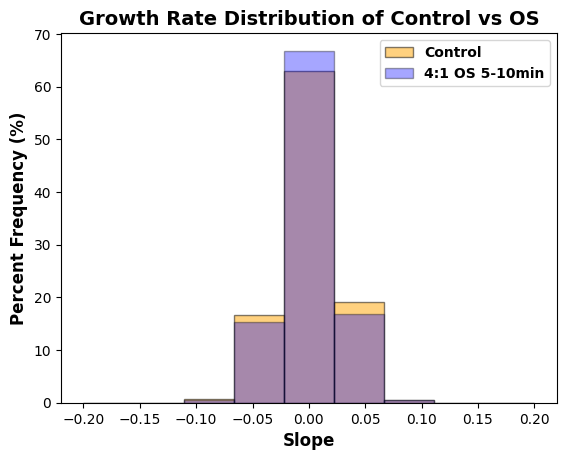

In [22]:
control_slopes = growth_distribution(tracks_channel_subset_control, framerate_msec, time_interval=10, forwardp=0)
os_slopes = growth_distribution(tracks_channel_subset_treatment, framerate_msec, time_interval=10, forwardp=0)

# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([control_slopes, os_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
control_weights = np.ones_like(control_slopes) / len(control_slopes) * 100
os_weights = np.ones_like(os_slopes) / len(os_slopes) * 100

plt.hist(control_slopes, bins=bins, weights = control_weights, color = 'orange', edgecolor='black', alpha=0.5, label=label1)
plt.hist(os_slopes, bins=bins, color = 'blue', weights = os_weights, edgecolor='black', alpha=0.35, label=label2)

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Rate Distribution of Control vs OS', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()